### Imports + setup

In [2]:
import pandas as pd
import numpy as np
import yaml
import os
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

os.chdir("..")
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

sns.set_theme(style="whitegrid")

# Business parameters from config
AVG_LOAN = config["profit"]["avg_loan_amount"]
INT_RATE = config["profit"]["avg_interest_rate"]
TERM_YRS = config["profit"]["avg_loan_term_years"]
LGD = config["profit"]["loss_given_default"]

INTEREST_REVENUE = AVG_LOAN * INT_RATE * TERM_YRS
LOSS_AMOUNT = AVG_LOAN * LGD

print(f"Interest revenue if repaid:  ${INTEREST_REVENUE:,.0f}")
print(f"Loss if defaulted:           ${LOSS_AMOUNT:,.0f}")

Interest revenue if repaid:  $5,400
Loss if defaulted:           $10,500


#### Load trained XGB + held-out test set

In [3]:
xgb_model = joblib.load("src/models/xgboost_model.joblib")
X_test = pd.read_parquet("src/models/X_test.parquet")
y_test = pd.read_parquet("src/models/y_test.parquet")["default"]

# Get default probabilities on the held-out test set saved from notebook 3.
p_default = xgb_model.predict_proba(X_test)[:, 1]
print(f"Test set: {len(X_test):,} loans")
print(f"Avg predicted default probability: {p_default.mean():.1%}")

Test set: 269,062 loans
Avg predicted default probability: 45.6%


#### Calculate expected profit per loan:

In [4]:
def expected_profit(p_def, interest_rev, loss_amt):
    p_repay = 1 - p_def
    return (p_repay * interest_rev) - (p_def * loss_amt)

test_profits = expected_profit(p_default, INTEREST_REVENUE, LOSS_AMOUNT)

results_df = X_test.copy()
results_df["p_default"]       = p_default
results_df["expected_profit"] = test_profits
results_df["actual_default"]  = y_test.values

print(f"Avg expected profit per loan: ${test_profits.mean():,.0f}")
print(f"Loans with positive expected profit: {(test_profits > 0).mean():.1%}")
results_df[["p_default", "expected_profit", "actual_default"]].head(10)

Avg expected profit per loan: $-1,846
Loans with positive expected profit: 28.9%


,p_default,expected_profit,actual_default
1311262,0.311691,444.108398,0
823606,0.425915,-1372.054688,0
196043,0.220748,1890.099609,0
810959,0.484941,-2310.559814,0
1157129,0.554391,-3414.821289,0
31964,0.626952,-4568.544434,1
398,0.608670,-4277.848145,1
869682,0.178439,2562.824707,0
1314407,0.607480,-4258.938477,0
803292,0.553169,-3395.382568,0


#### Profit cure

In [5]:
thresholds = np.arange(0.01, 0.99, 0.01)
portfolio_profits = []
approval_rates = []

for thresh in thresholds:
    approved = p_default < thresh
    n_approved = approved.sum()
    
    if n_approved == 0:
        portfolio_profits.append(0)
        approval_rates.append(0)
        continue
    
    profit = expected_profit(
        p_default[approved], 
        INTEREST_REVENUE, 
        LOSS_AMOUNT
    ).sum()
    
    portfolio_profits.append(profit)
    approval_rates.append(approved.mean())

portfolio_profits = np.array(portfolio_profits)
optimal_idx = np.argmax(portfolio_profits)
optimal_threshold = thresholds[optimal_idx]
max_profit = portfolio_profits[optimal_idx]
profit_at_05 = portfolio_profits[np.argmin(np.abs(thresholds - 0.5))]

print(f"Optimal threshold:         {optimal_threshold:.2f}")
print(f"Max portfolio profit:      ${max_profit:,.0f}")
print(f"Profit at 0.5 threshold:   ${profit_at_05:,.0f}")
print(f"Profit improvement:        ${max_profit - profit_at_05:,.0f}")

Optimal threshold:         0.34
Max portfolio profit:      $137,776,656
Profit at 0.5 threshold:   $38,282,676
Profit improvement:        $99,493,980


#### Plot the profit curve

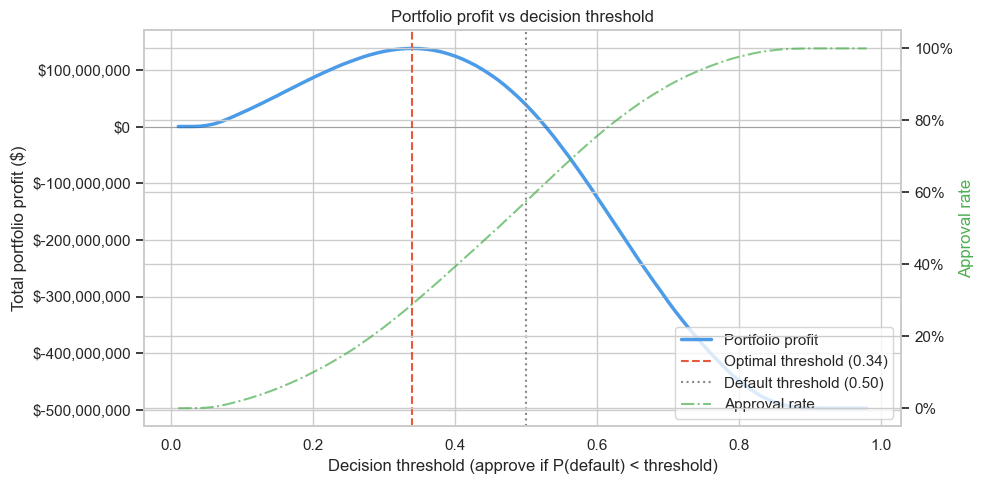

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(thresholds, portfolio_profits, color="#4C9BE8", linewidth=2.5, label="Portfolio profit")
ax1.axvline(optimal_threshold, color="#E8593C", linestyle="--", linewidth=1.5,
            label=f"Optimal threshold ({optimal_threshold:.2f})")
ax1.axvline(0.5, color="#888", linestyle=":", linewidth=1.5,
            label="Default threshold (0.50)")
ax1.axhline(0, color="black", linewidth=0.5, alpha=0.3)
ax1.set_xlabel("Decision threshold (approve if P(default) < threshold)")
ax1.set_ylabel("Total portfolio profit ($)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax2 = ax1.twinx()
ax2.plot(thresholds, approval_rates, color="#4CAF50", linewidth=1.5, 
         linestyle="-.", alpha=0.7, label="Approval rate")
ax2.set_ylabel("Approval rate", color="#4CAF50")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

ax1.set_title("Portfolio profit vs decision threshold")
plt.tight_layout()
plt.show()

#### Business insights

In [7]:
# Segment loans into risk buckets
results_df["risk_segment"] = pd.cut(
    results_df["p_default"],
    bins=[0, 0.10, 0.20, 0.30, 0.50, 1.0],
    labels=["Very Low (<10%)", "Low (10-20%)", 
            "Medium (20-30%)", "High (30-50%)", "Very High (>50%)"]
)

segment_summary = results_df.groupby("risk_segment", observed=True).agg(
    loan_count=("p_default", "count"),
    avg_p_default=("p_default", "mean"),
    avg_expected_profit=("expected_profit", "mean"),
    actual_default_rate=("actual_default", "mean")
).round(3)

print("Risk segment analysis:")
print(segment_summary.to_string())

Risk segment analysis:
                  loan_count  avg_p_default  avg_expected_profit  actual_default_rate
risk_segment                                                                         
Very Low (<10%)         5891          0.077          4178.680176                0.019
Low (10-20%)           20982          0.155          2935.110107                0.042
Medium (20-30%)        33773          0.253          1370.782959                0.076
High (30-50%)          93955          0.403         -1002.755005                0.145
Very High (>50%)      114461          0.634         -4674.152832                0.319


# *Decision engine*

In [8]:
def loan_decision(p_def, threshold, interest_rev, loss_amt):
    exp_profit = expected_profit(p_def, interest_rev, loss_amt)
    decision = "APPROVE" if p_def < threshold else "DENY"
    return {
        "p_default":        round(p_def, 4),
        "expected_profit":  round(exp_profit, 2),
        "decision":         decision,
        "threshold_used":   threshold
    }

# Example loans
print("Example decisions:\n")
for p in [0.05, 0.15, 0.25, 0.40, 0.60]:
    d = loan_decision(p, optimal_threshold, INTEREST_REVENUE, LOSS_AMOUNT)
    print(f"P(default)={d['p_default']:.2f} → {d['decision']:6s} | "
          f"Expected profit: ${d['expected_profit']:,.0f}")

Example decisions:

P(default)=0.05 → APPROVE | Expected profit: $4,605
P(default)=0.15 → APPROVE | Expected profit: $3,015
P(default)=0.25 → APPROVE | Expected profit: $1,425
P(default)=0.40 → DENY   | Expected profit: $-960
P(default)=0.60 → DENY   | Expected profit: $-4,140


### Save Profit Threshold

In [10]:
import os

os.makedirs("src/models", exist_ok=True)

# Model/test artifacts are produced in notebook 3; save only optimized threshold here.
joblib.dump(optimal_threshold, "src/models/optimal_threshold.joblib")

print(f"Threshold saved: {optimal_threshold:.2f}")
print(f"Test set referenced: {len(X_test):,} rows")

Model saved. Threshold: 0.34
Test set saved: 269,062 rows
